In [8]:
from typing import Dict
import math
import matplotlib.pyplot as plt

In [9]:
"""
1D Building Energy Model

This script solves the indoor sensible heat and specific humidity balance equations.
It uses an explicit Euler time-integration method. The equations replicate the
physics described in the WRF BEP-BEM documentation, upgraded with multi-surface 
prognostic temperatures and solar incidence geometry.
"""


class BuildingEnergyModel:
    def __init__(self, parameters: Dict[str, float]):
        """
        Initializes the model with building parameters and initial states.
        """
        # Building Geometry
        self.length_ew = parameters.get('length_ew', 10.0)       # East-West length (m)
        self.width_ns = parameters.get('width_ns', 10.0)         # North-South width (m)
        self.height = parameters.get('height', 2.5)              # Building height (m)
        
        # Computed Geometric Properties
        self.volume = self.length_ew * self.width_ns * self.height
        self.a_roof = self.length_ew * self.width_ns
        self.a_floor = self.length_ew * self.width_ns
        self.a_wall_n = self.length_ew * self.height
        self.a_wall_s = self.length_ew * self.height
        self.a_wall_e = self.width_ns * self.height
        self.a_wall_w = self.width_ns * self.height
        
        # Internal thermal mass (furniture, partition walls, floors)
        self.internal_mass_per_area = parameters.get('internal_mass_per_area', 150000.0) # J/m^2-K
        self.internal_heat_capacity = self.a_floor * self.internal_mass_per_area
        
        # Location and Air Properties
        self.lat_rad = math.radians(parameters.get('latitude', 38.9))
        self.doy = parameters.get('day_of_year', 172)
        self.rho = parameters.get('rho', 1.2)                  # Air density (kg/m^3)
        self.cp = parameters.get('cp', 1005.0)                 # Specific heat capacity of air (J/kg-K)
        
        # System Properties
        self.frac_win = parameters.get('frac_win', 0.15)       # Window area fraction for walls (-)
        self.cop_cool = parameters.get('cop_cool', 3.0)        # Coefficient of Performance for cooling
        self.cop_heat = parameters.get('cop_heat', 2.5)        # Coefficient of Performance for heating
        self.t_cool_target = parameters.get('tc_target', 297.0)# Cooling setpoint (K)
        self.t_heat_target = parameters.get('th_target', 293.0)# Heating setpoint (K)
        self.q_target = parameters.get('q_target', 0.012)      # Humidity setpoint (kg/kg)
        
        # Envelope physical properties (Applied uniformly to walls and roof for simplicity)
        self.env_thickness = parameters.get('wall_thickness', 0.20)       
        self.env_density = parameters.get('wall_density', 1800.0)           
        self.env_cp = parameters.get('wall_cp', 840.0)                     
        self.env_k = parameters.get('wall_k', 0.1)                       
        self.env_emiss = parameters.get('wall_emissivity', 0.9)     
        self.shgc = parameters.get('shgc', 0.4)                  
        
        # Surface Albedo
        self.wall_albedo = parameters.get('wall_albedo', 0.3)    # Wall albedo (-)
        self.roof_albedo = parameters.get('roof_albedo', 0.2)    # Roof albedo (-)
        
        # State variables
        self.t_in = parameters.get('t_init', 297.0)              
        self.q_in = parameters.get('q_init', 0.015)              
        
        # Prognostic temperatures for each envelope surface
        t_init_env = parameters.get('t_wall_init', 298.0)
        self.t_surf = {
            'Roof': t_init_env, 
            'N': t_init_env, 
            'S': t_init_env, 
            'E': t_init_env, 
            'W': t_init_env
        }

    def step(self, dt: float, forcing: Dict[str, float]) -> Dict[str, float]:
        """
        Advances the model by one time step (dt).
        """
        t_amb = forcing['t_amb']
        q_amb = forcing['q_amb']
        sw_in = forcing['sw_in']
        wind_speed = forcing['wind_speed']
        time_hours = forcing['time_hours']
        ac_on = forcing['ac_on']
        occup_sens = forcing['occup_sens']
        occup_lat = forcing['occup_lat']
        equip_sens = forcing['equip_sens']
        vent_rate = forcing['vent_rate']

        # 1. Solar Geometry & Incidence Calculations
        declination = 23.45 * (math.pi / 180.0) * math.sin(2.0 * math.pi / 365.0 * (284.0 + self.doy))
        hour_angle = (time_hours - 12.0) * math.pi / 12.0
        
        cos_zenith = math.sin(self.lat_rad) * math.sin(declination) + math.cos(self.lat_rad) * math.cos(declination) * math.cos(hour_angle)
        
        # Clamp to prevent math domain error due to floating point inaccuracies
        cos_zenith = max(-1.0, min(1.0, cos_zenith))
        
        if cos_zenith > 0.0 and sw_in > 0.0:
            zenith = math.acos(cos_zenith)
            # Add epsilon to prevent division by zero at exact overhead zenith
            sin_zenith = max(0.0001, math.sin(zenith))
            
            # Calculate solar azimuth (0=N, pi/2=W, pi=S, -pi/2=E)
            sin_az = (math.cos(declination) * math.sin(hour_angle)) / sin_zenith
            cos_az = (math.sin(declination) * math.cos(self.lat_rad) - math.cos(declination) * math.sin(self.lat_rad) * math.cos(hour_angle)) / sin_zenith
            azimuth = math.atan2(sin_az, cos_az)
            
            # Partition GHI into Direct Normal and Diffuse components
            # Clamp cos_zenith to prevent physically unrealistic spikes at sunrise/sunset
            sw_dir_norm = min(1361.0, (sw_in * 0.8) / max(0.05, cos_zenith))
            sw_diffuse = sw_in * 0.2
        else:
            zenith = math.pi / 2.0
            azimuth = 0.0
            sw_dir_norm = 0.0
            sw_diffuse = sw_in
            
        # Incident radiation on each surface
        surf_azimuths = {'N': 0.0, 'W': math.pi/2, 'S': math.pi, 'E': -math.pi/2}
        sw_inc = {'Roof': sw_in}
        
        for direction, az in surf_azimuths.items():
            cos_inc = math.sin(zenith) * math.cos(azimuth - az)
            cos_inc = max(0.0, cos_inc) # Sun must be in front of the wall
            # Vertical surfaces get direct incidence + half the diffuse sky
            sw_inc[direction] = (sw_dir_norm * cos_inc) + (sw_diffuse * 0.5)

        # 2. Multi-Surface Envelope Energy Balance
        h_out = 5.7 + 3.8 * wind_speed
        sigma = 5.67e-8
        t_sky = t_amb - 15.0 # Effective sky temperature approximation
        
        q_cond_in_total = 0.0
        q_win_total = 0.0
        
        areas = {
            'Roof': self.a_roof, 'N': self.a_wall_n, 
            'S': self.a_wall_s, 'E': self.a_wall_e, 'W': self.a_wall_w
        }
        
        for surf, a_surf in areas.items():
            # Assume windows are only on vertical walls
            frac_win_surf = 0.0 if surf == 'Roof' else self.frac_win
            a_opaque = a_surf * (1.0 - frac_win_surf)
            a_win = a_surf * frac_win_surf
            
            t_s = self.t_surf[surf]
            sw_incident = sw_inc[surf]
            
            # Determine surface absorptivity based on albedo
            surf_albedo = self.roof_albedo if surf == 'Roof' else self.wall_albedo
            surf_abs = 1.0 - surf_albedo
            
            # Surface Energy Fluxes
            q_sw_abs = sw_incident * a_opaque * surf_abs
            q_lw_net = self.env_emiss * sigma * a_opaque * ((t_s ** 4) - (t_sky ** 4))
            q_conv_out = h_out * a_opaque * (t_s - t_amb)
            q_cond_in = (self.env_k / self.env_thickness) * a_opaque * (t_s - self.t_in)
            
            # Update prognostic envelope temperature
            heat_cap = a_opaque * self.env_thickness * self.env_density * self.env_cp
            q_surf_total = q_sw_abs - q_conv_out - q_cond_in - q_lw_net
            self.t_surf[surf] = t_s + (dt * q_surf_total) / heat_cap
            
            # Aggregate heat entering the zone
            q_cond_in_total += q_cond_in
            q_win_total += sw_incident * a_win * self.shgc

        # 3. Sensible Heat Balance Components
        q_int = occup_sens + equip_sens
        
        mass_flow = vent_rate * self.rho
        q_vent = mass_flow * self.cp * (t_amb - self.t_in)
        
        # Ground heat transfer (Using a stable deep-ground temperature)
        t_ground = forcing.get('t_ground', 295.0)
        q_floor = (self.env_k / self.env_thickness) * self.a_floor * (t_ground - self.t_in)
        
        # Total zone heat capacity (air + internal mass)
        heat_capacity = (self.volume * self.rho * self.cp) + self.internal_heat_capacity
        q_total_no_hvac = q_int + q_win_total + q_cond_in_total + q_vent + q_floor
        
        # Predict indoor temperature without HVAC intervention
        t_in_next = self.t_in + (dt * q_total_no_hvac) / heat_capacity
        
        # Predict indoor specific humidity without HVAC intervention
        e_int = occup_lat
        e_vent = mass_flow * (q_amb - self.q_in)
        e_total_no_hvac = e_int + e_vent
        q_in_next = self.q_in + (dt * e_total_no_hvac) / (self.volume * self.rho)
        
        q_hvac = 0.0
        sens_cool_out = 0.0
        sens_heat_out = 0.0
        e_hvac = 0.0
        
        # 4. HVAC Operation and Anthropogenic Heat
        if ac_on:
            if t_in_next > self.t_cool_target:
                q_hvac = (self.t_cool_target - t_in_next) * heat_capacity / dt
                sens_cool_out = abs(q_hvac) * (1.0 + (1.0 / self.cop_cool))
                
            elif t_in_next < self.t_heat_target:
                q_hvac = (self.t_heat_target - t_in_next) * heat_capacity / dt
                sens_heat_out = abs(q_hvac) * (1.0 - (1.0 / self.cop_heat))
                
            if q_in_next > self.q_target:
                req_e_hvac = (q_in_next - self.q_target) * (self.volume * self.rho) / dt
                max_e_hvac = (self.volume * self.rho * max(0.0, self.q_in)) / dt
                e_hvac = min(req_e_hvac, max_e_hvac)
        
        # Update indoor temperature and humidity
        q_total = q_total_no_hvac + q_hvac
        self.t_in = self.t_in + (dt * q_total) / heat_capacity
        
        e_total = e_total_no_hvac - e_hvac
        self.q_in = self.q_in + (dt * e_total) / (self.volume * self.rho)
        self.q_in = max(0.0, self.q_in)
        
        return {
            't_in': self.t_in,
            'q_in': self.q_in,
            'sens_cool_out': sens_cool_out,
            'sens_heat_out': sens_heat_out,
            't_roof': self.t_surf['Roof'],
            't_wall_s': self.t_surf['S'],
            't_wall_n': self.t_surf['N'],
            't_wall_e': self.t_surf['E'],
            't_wall_w': self.t_surf['W']
        }



Hour   | T_Roof(K) | T_South(K) | T_in(K) | Q_in(kg/kg) | AC_Waste_Heat(W)
---------------------------------------------------------------------------
   0.0 |    297.99 |     297.99 |  297.00 |      0.0153 |            0.00
   1.0 |    297.39 |     297.39 |  297.09 |      0.0255 |            0.00
   2.0 |    296.72 |     296.72 |  297.15 |      0.0291 |            0.00
   3.0 |    296.05 |     296.05 |  297.17 |      0.0304 |            0.00
   4.0 |    295.44 |     295.44 |  297.18 |      0.0309 |            0.00
   5.0 |    294.96 |     294.96 |  297.17 |      0.0309 |            0.00
   6.0 |    294.65 |     294.65 |  297.16 |      0.0307 |            0.00
   7.0 |    295.50 |     294.63 |  297.27 |      0.0304 |            0.00
   8.0 |    298.15 |     294.97 |  297.50 |      0.0300 |            0.00
   9.0 |    302.12 |     295.84 |  297.82 |      0.0296 |            0.00
  10.0 |    306.94 |     297.48 |  298.22 |      0.0291 |            0.00
  11.0 |    312.10 |     299.62 |  

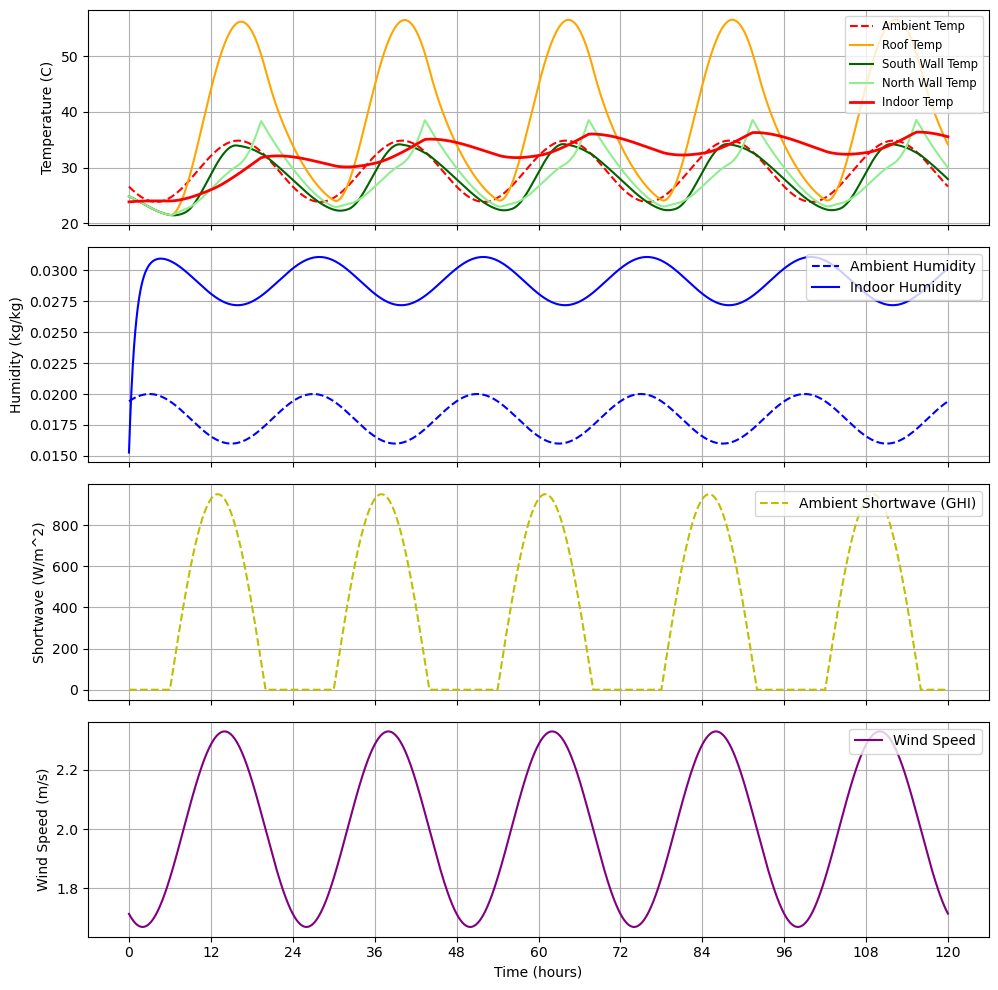

In [10]:
# Execution test

params = {
    'length_ew': 10.0,         # Building is 10m x 20m x 2.5m = 500m^3
    'width_ns': 20.0,
    'height': 2.5,
    'latitude': 38.9,          # Washington DC
    'day_of_year': 172,        # Summer Solstice (Approx June 21)
    'rho': 1.2,
    'cp': 1005.0,
    'frac_win': 0.15,
    'cop_cool': 3.0,
    'cop_heat': 2.5,
    'tc_target': 297.0,
    'th_target': 293.0,
    'q_target': 0.012,
    't_init': 297.0,
    'q_init': 0.015,
    'wall_thickness': 0.20,
    'wall_density': 1800.0,
    'wall_cp': 840.0,
    'wall_k': 0.1,             
    'wall_albedo': 0.3,        
    'roof_albedo': 0.2,        
    'wall_emissivity': 0.9,
    'shgc': 0.4,               
    'internal_mass_per_area': 150000.0, # Internal thermal mass (J/m^2-K)
    't_wall_init': 298.0
}

model = BuildingEnergyModel(params)

# 5-day simulation with a 60-second time step
dt = 60.0 
steps = 1440 * 5

t_amb_series = []
q_amb_series = []
sw_in_series = []
ac_on_series = []
wind_speed_series = []

# Generate typical Washington, DC summer day forcing data
for i in range(steps):
    h = (i * dt) / 3600.0
    
    # Temperature: Min 297 K (75 F) at 4:00 AM, Max 308 K (95 F) at 4:00 PM
    t_amb = 302.5 - 5.5 * math.cos(math.pi * (h - 4.0) / 12.0)
    t_amb_series.append(t_amb)
    
    # Humidity: High baseline, slight dip during afternoon heating
    q_amb = 0.018 - 0.002 * math.cos(math.pi * (h - 15.0) / 12.0)
    q_amb_series.append(q_amb)
    
    # Shortwave Radiation: Peak at 1:00 PM, zero before 6:00 AM and after 8:00 PM
    h_mod = h % 24.0
    if 6.0 < h_mod < 20.0:
        sw_in = 950.0 * math.sin(math.pi * (h_mod - 6.0) / 14.0)
    else:
        sw_in = 0.0
    sw_in_series.append(sw_in)
    
    # AC Schedule: Disabled for testing free-floating indoor temperatures
    ac_on_series.append(False)
        
    # Wind speed profile (m/s)
    wind_speed = 2.0 + 0.33 * math.sin(math.pi * (h - 8.0) / 12.0)
    wind_speed_series.append(wind_speed)

print("Hour   | T_Roof(K) | T_South(K) | T_in(K) | Q_in(kg/kg) | AC_Waste_Heat(W)")
print("-" * 75)

t_in_results = []
t_roof_results = []
t_wall_s_results = []
t_wall_n_results = []
q_in_results = []
time_series = []

for step in range(steps):
    time_hours = (step * dt) / 3600.0
    
    forcing_step = {
        'time_hours': time_hours,
        't_amb': t_amb_series[step],
        'q_amb': q_amb_series[step],
        'sw_in': sw_in_series[step],
        'wind_speed': wind_speed_series[step],
        'ac_on': ac_on_series[step],
        'occup_sens': 200.0,
        'occup_lat': 0.002,
        'equip_sens': 300.0,
        'vent_rate': 0.15
    }
    
    output = model.step(dt, forcing_step)
    
    t_in_results.append(output['t_in'])
    t_roof_results.append(output['t_roof'])
    t_wall_s_results.append(output['t_wall_s'])
    t_wall_n_results.append(output['t_wall_n'])
    q_in_results.append(output['q_in'])
    time_series.append(time_hours)
    
    if step % 60 == 0:
        print(f"{time_hours:6.1f} | {output['t_roof']:9.2f} | {output['t_wall_s']:10.2f} | {output['t_in']:7.2f} | {output['q_in']:11.4f} | {output['sens_cool_out']:15.2f}")

# Convert temperatures to Celsius for plotting
t_amb_degc = [t - 273.15 for t in t_amb_series]
t_roof_degc = [t - 273.15 for t in t_roof_results]
t_wall_s_degc = [t - 273.15 for t in t_wall_s_results]
t_wall_n_degc = [t - 273.15 for t in t_wall_n_results]
t_in_degc = [t - 273.15 for t in t_in_results]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

ax1.plot(time_series, t_amb_degc, color='red', linestyle='--', label='Ambient Temp')
ax1.plot(time_series, t_roof_degc, color='orange', linestyle='-', label='Roof Temp')
ax1.plot(time_series, t_wall_s_degc, color='darkgreen', linestyle='-', label='South Wall Temp')
ax1.plot(time_series, t_wall_n_degc, color='lightgreen', linestyle='-', label='North Wall Temp')
ax1.plot(time_series, t_in_degc, color='red', linestyle='-', linewidth=2, label='Indoor Temp')

# Add gray markers for AC operation
ac_label_added = False
in_ac = False
start_t = 0
for i, is_on in enumerate(ac_on_series):
    if is_on and not in_ac:
        start_t = time_series[i]
        in_ac = True
    elif not is_on and in_ac:
        end_t = time_series[i-1]
        label = 'AC Active' if not ac_label_added else None
        ax1.axvspan(start_t, end_t, color='gray', alpha=0.2, label=label)
        ax2.axvspan(start_t, end_t, color='gray', alpha=0.2)
        ac_label_added = True
        in_ac = False
if in_ac:
    label = 'AC Active' if not ac_label_added else None
    ax1.axvspan(start_t, time_series[-1], color='gray', alpha=0.2, label=label)
    ax2.axvspan(start_t, time_series[-1], color='gray', alpha=0.2)

ax1.set_ylabel('Temperature (C)')
ax1.legend(loc='upper right', fontsize='small')
ax1.grid(True)

ax2.plot(time_series, q_amb_series, color='blue', linestyle='--', label='Ambient Humidity')
ax2.plot(time_series, q_in_results, color='blue', linestyle='-', label='Indoor Humidity')
ax2.set_ylabel('Humidity (kg/kg)')
ax2.legend(loc='upper right')
ax2.grid(True)

ax3.plot(time_series, sw_in_series, color='y', linestyle='--', label='Ambient Shortwave (GHI)')
ax3.set_ylabel('Shortwave (W/m^2)')
ax3.legend(loc='upper right')
ax3.grid(True)

ax4.plot(time_series, wind_speed_series, color='purple', linestyle='-', label='Wind Speed')
ax4.set_ylabel('Wind Speed (m/s)')
ax4.set_xlabel('Time (hours)')
ax4.set_xticks(range(0, 121, 12))  # Adjust x-ticks to support 120 hours (5 days)
ax4.legend(loc='upper right')
ax4.grid(True)

plt.tight_layout()
plt.show()

In [5]:
simpleBEM.BuildingEnergyModel()

AttributeError: module 'simpleBEM' has no attribute 'BuildingEnergyModel'